In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [93]:
proj_dir = os.path.join(Path.home(), 'Documents', 'WorkSpace', 'corpus-comparison')
analysis_dir = os.path.join(proj_dir, 'analysis')
corpora_dir = os.path.join(proj_dir, 'corpora')

print(f"Project directory: {proj_dir}")
print(f"Analysis directory: {analysis_dir}")
print(f"Corpora directory: {corpora_dir}")

Project directory: /Users/bagjuhyeon/Documents/WorkSpace/corpus-comparison
Analysis directory: /Users/bagjuhyeon/Documents/WorkSpace/corpus-comparison/analysis
Corpora directory: /Users/bagjuhyeon/Documents/WorkSpace/corpus-comparison/corpora


In [86]:
KE_E_final_df = pd.read_excel(os.path.join(corpora_dir, 'merged_corpora', 'KE_E_final(250927-1500)-zeroIn.xlsx'))
KE_E_final_df

,Word,Freq_KE,Freq_KE(EXAM),Freq_KE(TEXTBOOK),Ortho_N_KE,Ortho_N_KE(EXAM),Ortho_N_KE(TEXTBOOK),OLD_KE,OLD_KE(EXAM),OLD_KE(TEXTBOOK),...,RFreq_HAL(130),RFreq_HAL(160),RFreq_SUBTLEX,Zipf_KE,Zipf_KE(EXAM),Zipf_KE(TEXTBOOK),Zipf_KF,Zipf_HAL(130),Zipf_HAL(160),Zipf_SUBTLEX
0,a,17505,9773.0,7732.0,1.0,1.0,1.0,1.45,1.45,1.45,...,81620.200000,66316.41250,20415.27,7.360356,7.341828,7.371453,7.340727,7.911473,7.821357,7.309323
1,aah,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.707692,1.38750,52.71,3.117169,NaN,NaN,3.275558,3.234037,3.143921,4.721422
2,aaron,7,1.0,6.0,1.0,1.0,0.0,1.85,1.95,2.00,...,83.123077,67.53750,14.65,4.020259,3.652785,4.328203,3.877618,4.919437,4.829321,4.165786
3,aback,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.976923,2.41875,0.29,3.117169,NaN,NaN,3.451649,3.474564,3.384448,2.490180
4,abacus,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.946154,3.20625,0.24,3.117169,NaN,NaN,2.974528,3.596695,3.506579,2.413686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40476,zoom,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,37.846154,30.75000,3.55,3.117169,NaN,NaN,2.974528,4.577785,4.487669,3.551988
40477,zooming,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.023077,3.26875,0.63,3.117169,NaN,NaN,3.275558,3.605063,3.514947,2.812019
40478,zooms,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.961538,2.40625,0.06,3.117169,NaN,NaN,3.275558,3.472319,3.382203,1.900324
40479,zucchini,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.415385,1.96250,0.96,3.117169,NaN,NaN,2.974528,3.384042,3.293927,2.990420


In [88]:
KE_E_final_df.columns

Index(['Word', 'Freq_KE', 'Freq_KE(EXAM)', 'Freq_KE(TEXTBOOK)', 'Ortho_N_KE',
       'Ortho_N_KE(EXAM)', 'Ortho_N_KE(TEXTBOOK)', 'OLD_KE', 'OLD_KE(EXAM)',
       'OLD_KE(TEXTBOOK)', 'Length', 'Freq_KF', 'Freq_HAL', 'Freq_SUBTLEX',
       'SUBTLCD', 'Ortho_N', 'Phono_N', 'OLD', 'PLD', 'Concreteness_Rating',
       'Semantic_Neighborhood_Density', 'Semantic_Neighbors',
       'Semantic_Diversity', 'Age_Of_Acquisition', 'Body_Object_Interaction',
       'Emotional_Valence', 'Emotional_Arousal', 'Emotional_Dominance',
       'Assoc_Freq_R1', 'Assoc_Types_R1', 'Assoc_Freq_R123',
       'Assoc_Types_R123', 'POS', 'LDT_RT_MEAN', 'LDT_RT_ZSCORE', 'LDT_RT_SD',
       'LDT_RT_OBS', 'LDT_ACC_MEAN', 'NMG_RT_MEAN', 'NMG_RT_ZSCORE',
       'NMG_RT_SD', 'NMG_RT_OBS', 'NMG_ACC_MEAN', 'RFreq_KE', 'RFreq_KE(EXAM)',
       'RFreq_KE(TEXTBOOK)', 'RFreq_KF', 'RFreq_HAL(130)', 'RFreq_HAL(160)',
       'RFreq_SUBTLEX', 'Zipf_KE', 'Zipf_KE(EXAM)', 'Zipf_KE(TEXTBOOK)',
       'Zipf_KF', 'Zipf_HAL(130)', 'Zipf_

In [89]:
# E-lexicon에서 LDT behavior exp results가 있는 단어들.
exp_cols = ['Word', 'Length', 'LDT_RT_MEAN', 'LDT_RT_SD', 'LDT_RT_OBS', 'LDT_ACC_MEAN']
mask = KE_E_final_df[exp_cols].isna().any(axis=1)
ELP_LDT_data = KE_E_final_df[~mask].reset_index(drop=True)

ELP_LDT_data

,Word,Freq_KE,Freq_KE(EXAM),Freq_KE(TEXTBOOK),Ortho_N_KE,Ortho_N_KE(EXAM),Ortho_N_KE(TEXTBOOK),OLD_KE,OLD_KE(EXAM),OLD_KE(TEXTBOOK),...,RFreq_HAL(130),RFreq_HAL(160),RFreq_SUBTLEX,Zipf_KE,Zipf_KE(EXAM),Zipf_KE(TEXTBOOK),Zipf_KF,Zipf_HAL(130),Zipf_HAL(160),Zipf_SUBTLEX
0,a,17505,9773.0,7732.0,1.0,1.0,1.0,1.45,1.45,1.45,...,81620.200000,66316.41250,20415.27,7.360356,7.341828,7.371453,7.340727,7.911473,7.821357,7.309323
1,aah,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.707692,1.38750,52.71,3.117169,NaN,NaN,3.275558,3.234037,3.143921,4.721422
2,aaron,7,1.0,6.0,1.0,1.0,0.0,1.85,1.95,2.00,...,83.123077,67.53750,14.65,4.020259,3.652785,4.328203,3.877618,4.919437,4.829321,4.165786
3,aback,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.976923,2.41875,0.29,3.117169,NaN,NaN,3.451649,3.474564,3.384448,2.490180
4,abacus,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.946154,3.20625,0.24,3.117169,NaN,NaN,2.974528,3.596695,3.506579,2.413686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40444,zoom,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,37.846154,30.75000,3.55,3.117169,NaN,NaN,2.974528,4.577785,4.487669,3.551988
40445,zooming,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.023077,3.26875,0.63,3.117169,NaN,NaN,3.275558,3.605063,3.514947,2.812019
40446,zooms,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.961538,2.40625,0.06,3.117169,NaN,NaN,3.275558,3.472319,3.382203,1.900324
40447,zucchini,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.415385,1.96250,0.96,3.117169,NaN,NaN,2.974528,3.384042,3.293927,2.990420


In [90]:
# 분석에 사용할 빈도느 수는 SUBTLEX, KE이니 두 모퍼스 모두에서 최소 빈도가 1 이상인걸로 추출.
mask =  (ELP_LDT_data['Freq_KE'] > 0) & (ELP_LDT_data['Freq_SUBTLEX'] > 0)
ELP_LDT_data = ELP_LDT_data[mask]
ELP_LDT_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15995 entries, 0 to 40442
Data columns (total 57 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Word                           15995 non-null  object 
 1   Freq_KE                        15995 non-null  int64  
 2   Freq_KE(EXAM)                  13727 non-null  float64
 3   Freq_KE(TEXTBOOK)              11658 non-null  float64
 4   Ortho_N_KE                     15995 non-null  float64
 5   Ortho_N_KE(EXAM)               13727 non-null  float64
 6   Ortho_N_KE(TEXTBOOK)           11658 non-null  float64
 7   OLD_KE                         15995 non-null  float64
 8   OLD_KE(EXAM)                   13727 non-null  float64
 9   OLD_KE(TEXTBOOK)               11658 non-null  float64
 10  Length                         15995 non-null  int64  
 11  Freq_KF                        15995 non-null  int64  
 12  Freq_HAL                       15995 non-null  int6

In [101]:
ELP_LDT_data_path = os.path.join(corpora_dir, 'behavior-exp', 'ELP-LDT(250927-1800).xlsx')
ELP_LDT_data.reset_index(drop=True).to_excel(ELP_LDT_data_path, index=False)

In [117]:
ELP_LDT_data.sort_values('Freq_KE', ascending=False, inplace=True)
ELP_LDT_data.reset_index(drop=True, inplace=True)
ELP_LDT_data['KE_rank'] = ELP_LDT_data.index + 1
ELP_LDT_data.sort_values('Freq_SUBTLEX', ascending=False, inplace=True)
ELP_LDT_data.reset_index(drop=True, inplace=True)
ELP_LDT_data['SUBTLEX_rank'] = ELP_LDT_data.index + 1

In [147]:
ELP_LDT_data

,Word,Freq_KE,Freq_KE(EXAM),Freq_KE(TEXTBOOK),Ortho_N_KE,Ortho_N_KE(EXAM),Ortho_N_KE(TEXTBOOK),OLD_KE,OLD_KE(EXAM),OLD_KE(TEXTBOOK),...,RFreq_SUBTLEX,Zipf_KE,Zipf_KE(EXAM),Zipf_KE(TEXTBOOK),Zipf_KF,Zipf_HAL(130),Zipf_HAL(160),Zipf_SUBTLEX,KE_rank,SUBTLEX_rank
0,you,10292,6671.0,3621.0,1.0,1.0,0.0,1.80,1.80,1.85,...,41857.12,7.129711,7.176011,7.042054,6.491328,7.587342,7.497226,7.621137,8,1
1,i,11165,7204.0,3961.0,1.0,1.0,1.0,1.50,1.55,1.50,...,39971.16,7.165066,7.209389,7.081020,6.688354,7.743267,7.653151,7.601115,7,2
2,the,38303,21540.0,16763.0,3.0,2.0,3.0,1.55,1.60,1.55,...,29449.18,7.700413,7.685021,7.707483,7.819452,8.249326,8.159210,7.468441,1,3
3,to,21665,12665.0,9000.0,6.0,4.0,6.0,1.20,1.35,1.25,...,22677.84,7.452948,7.454395,7.437396,7.392000,7.988209,7.898094,7.354970,2,4
4,a,17505,9773.0,7732.0,1.0,1.0,1.0,1.45,1.45,1.45,...,20415.27,7.360356,7.341828,7.371453,7.340727,7.911473,7.821357,7.309323,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15990,determinate,1,1.0,NaN,0.0,0.0,NaN,3.10,3.35,NaN,...,0.02,3.418199,3.652785,NaN,3.275558,2.911038,2.820922,1.597149,13842,15991
15991,calorimeter,1,1.0,NaN,0.0,0.0,NaN,4.60,4.75,NaN,...,0.02,3.418199,3.652785,NaN,3.451649,2.915116,2.825000,1.597149,13881,15992
15992,paleness,1,NaN,1.0,0.0,NaN,0.0,2.75,NaN,2.80,...,0.02,3.418199,NaN,3.784135,3.275558,2.265943,2.175827,1.597149,13928,15993
15993,premonitory,3,3.0,NaN,0.0,0.0,NaN,4.40,4.45,NaN,...,0.02,3.719229,3.953815,NaN,3.275558,1.584702,1.494586,1.597149,9317,15994


In [148]:
# rank 정보를 % 정보로 변환
ELP_LDT_data['KE_rank'] = ELP_LDT_data['KE_rank'] / len(ELP_LDT_data) * 100.0
ELP_LDT_data['SUBTLEX_rank'] = ELP_LDT_data['SUBTLEX_rank'] / len(ELP_LDT_data) * 100.0

In [150]:
ELP_LDT_data['SUBTLEX_rank']

0          0.006252
1          0.012504
2          0.018756
3          0.025008
4          0.031260
            ...    
15990     99.974992
15991     99.981244
15992     99.987496
15993     99.993748
15994    100.000000
Name: SUBTLEX_rank, Length: 15995, dtype: float64

In [131]:
ELP_LDT_data[['Zipf_SUBTLEX', 'Zipf_KE']].corr(method='spearman')

,Zipf_SUBTLEX,Zipf_KE
Zipf_SUBTLEX,1.000000,0.678456
Zipf_KE,0.678456,1.000000


In [168]:
def plot_word_group_ranks_by_corpus(df, word_col, rank_columns, word_groups, group_names=None, figsize=(15, 8)):
    """
    HF/LF 그룹의 단어들을 입력받아 코퍼스별 rank 위치를 boxplot으로 시각화
    """
    
    if group_names is None:
        group_names = [f'Group {i+1}' for i in range(len(word_groups))]
    
    # seaborn 스타일 설정
    sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'AppleGothic'
    
    # 데이터 준비
    plot_data = []
    
    for corpus_col in rank_columns:
        for group_words, group_name in zip(word_groups, group_names):
            # 해당 그룹의 단어들이 데이터프레임에 있는지 확인
            available_words = [word for word in group_words if word in df[word_col].values]
            
            if available_words:
                # 해당 단어들의 rank 값 추출
                mask = df[word_col].isin(available_words)
                ranks = df[mask][corpus_col].values
                
                # 각 rank 값에 대해 데이터 포인트 추가
                for rank in ranks:
                    plot_data.append({
                        'Corpus': corpus_col,
                        'Group': group_name,
                        'Rank': rank
                    })
            else:
                print(f"Warning: {group_name} 그룹의 단어들이 데이터에 없습니다.")
    
    # DataFrame으로 변환
    plot_df = pd.DataFrame(plot_data)
    
    if plot_df.empty:
        print("그래프를 그릴 데이터가 없습니다.")
        return None
    
    # 그래프 생성
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Boxplot 그리기
    sns.boxplot(data=plot_df, x='Corpus', y='Rank', hue='Group', ax=ax)
    
    # 개별 데이터 포인트 표시 (strip plot) - legend=False로 중복 legend 방지
    sns.stripplot(data=plot_df, x='Corpus', y='Rank', hue='Group', 
                  dodge=True, size=6, alpha=0.6, legend=False, ax=ax)
    
    # y축 반전 - 수치가 작은 값이 위로 가도록
    ax.invert_yaxis()
    
    # 축 레이블 및 제목 설정
    ax.set_xlabel('Corpus', fontsize=14, fontweight='bold')
    ax.set_ylabel('Relative Rank Position (%)', fontsize=14, fontweight='bold')
    ax.set_title('Word Group Rank Positions Across Corpora', fontsize=16, fontweight='bold')
    
    # y축 범위 설정 (0-100%)
    ax.set_ylim(100, 0)
    
    # 그리드 설정
    ax.grid(True, alpha=0.3)
    
    # 축 스타일 개선
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    
    # 레이아웃 조정
    plt.tight_layout()
    plt.show()
    
    # 통계 정보 출력
    print("\n=== 그룹별 Rank 통계 ===")
    for corpus in rank_columns:
        print(f"\n{corpus}:")
        for group in group_names:
            group_data = plot_df[(plot_df['Corpus'] == corpus) & (plot_df['Group'] == group)]['Rank']
            if len(group_data) > 0:
                print(f"  {group}: 평균={group_data.mean():.2f}%, 중앙값={group_data.median():.2f}%, 표준편차={group_data.std():.2f}%")
    
    return fig, plot_df

In [178]:
ELP_LDT_data['Zipf_SUBTLEX'] .describe()

count    15995.000000
mean         3.471007
std          0.850980
min          1.597149
25%          2.885637
50%          3.405841
75%          3.991462
max          7.621137
Name: Zipf_SUBTLEX, dtype: float64

In [196]:
mask_diff = ELP_LDT_data['KE_rank'] - ELP_LDT_data['SUBTLEX_rank'] > 25 # KE에서 더 저빈도
mask_stable = abs(ELP_LDT_data['KE_rank'] - ELP_LDT_data['SUBTLEX_rank']) < 1 # 두 코퍼스 모두에서 stable한 빈도 단어들

# subltex 기준 빈도수 구간 분할
mask1 = (2 <= ELP_LDT_data['Zipf_SUBTLEX']) & (ELP_LDT_data['Zipf_SUBTLEX'] < 3)
mask2 = (3 <= ELP_LDT_data['Zipf_SUBTLEX']) & (ELP_LDT_data['Zipf_SUBTLEX'] < 4)
mask3 = (4 <= ELP_LDT_data['Zipf_SUBTLEX']) & (ELP_LDT_data['Zipf_SUBTLEX'] < 5)
mask4 = (5 <= ELP_LDT_data['Zipf_SUBTLEX']) & (ELP_LDT_data['Zipf_SUBTLEX'] < 6)
mask5 = (6 <= ELP_LDT_data['Zipf_SUBTLEX']) & (ELP_LDT_data['Zipf_SUBTLEX'] < 7)

print(f"Word count: {len(ELP_LDT_data[mask_diff & mask1])} in Zipf-SUBTLEX range [2,3)")
print(f"Word count: {len(ELP_LDT_data[mask_diff & mask2])} in Zipf-SUBTLEX range [3,4)")
print(f"Word count: {len(ELP_LDT_data[mask_diff & mask3])} in Zipf-SUBTLEX range [4,5)")
print(f"Word count: {len(ELP_LDT_data[mask_diff & mask4])} in Zipf-SUBTLEX range [5,6)")
print(f"Word count: {len(ELP_LDT_data[mask_diff & mask5])} in Zipf-SUBTLEX range [6,7)")

Word count: 24 in Zipf-SUBTLEX range [2,3)
Word count: 1498 in Zipf-SUBTLEX range [3,4)
Word count: 580 in Zipf-SUBTLEX range [4,5)
Word count: 24 in Zipf-SUBTLEX range [5,6)
Word count: 0 in Zipf-SUBTLEX range [6,7)


hf1_words: 24
hf2_words: 24
lf_words: 24


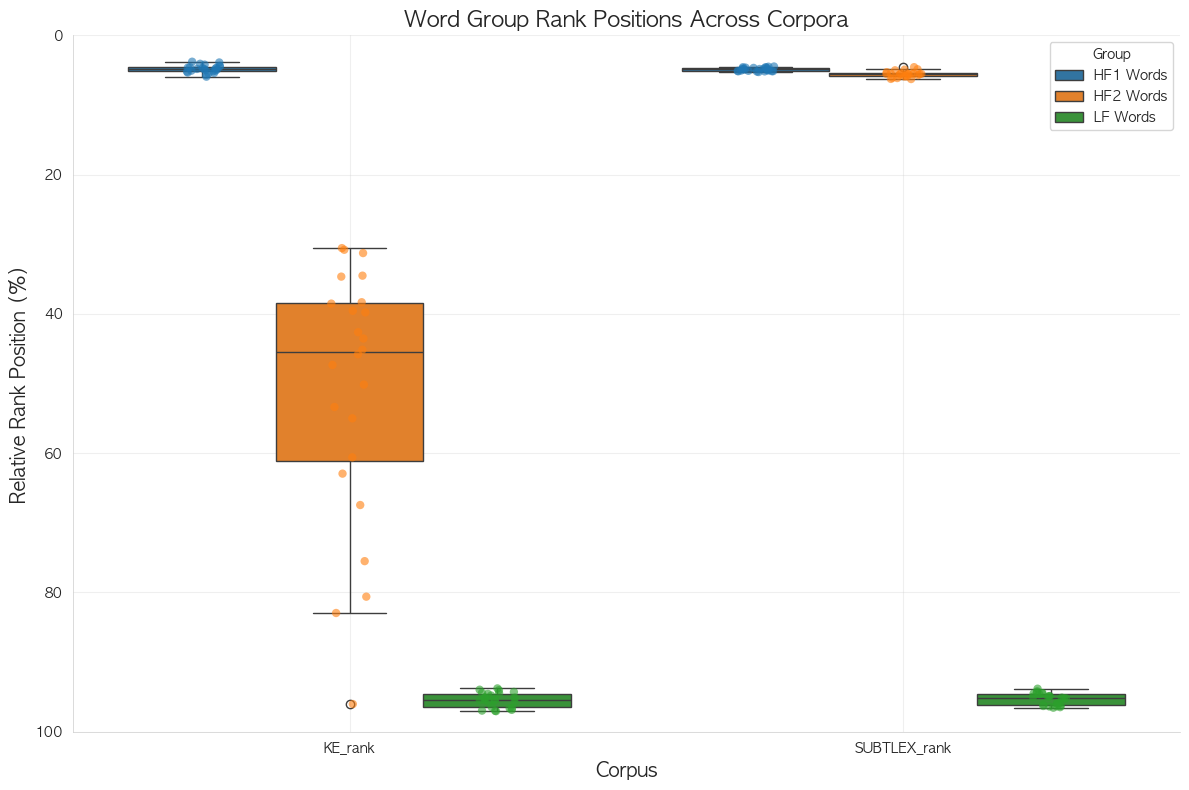


=== 그룹별 Rank 통계 ===

KE_rank:
  HF1 Words: 평균=4.84%, 중앙값=4.84%, 표준편차=0.54%
  HF2 Words: 평균=51.13%, 중앙값=45.48%, 표준편차=18.15%
  LF Words: 평균=95.44%, 중앙값=95.40%, 표준편차=1.04%

SUBTLEX_rank:
  HF1 Words: 평균=4.89%, 중앙값=4.88%, 표준편차=0.25%
  HF2 Words: 평균=5.58%, 중앙값=5.56%, 표준편차=0.43%
  LF Words: 평균=95.33%, 중앙값=95.15%, 표준편차=0.84%


In [198]:
hf1_words = ELP_LDT_data[mask_stable & mask3]['Word'][:24]
hf2_words = ELP_LDT_data[mask_diff & mask3]['Word'][:24]

# LF 그룹 (저빈도 단어들) 
lf_words = ELP_LDT_data[mask_stable & mask1]['Word'][-24:]

word_groups = [hf1_words, hf2_words, lf_words]
group_names = ['HF1 Words', 'HF2 Words', 'LF Words']
rank_columns = ['KE_rank', 'SUBTLEX_rank']

print(f"hf1_words: {len(hf1_words)}")
print(f"hf2_words: {len(hf2_words)}")
print(f"lf_words: {len(lf_words)}")

# 함수 실행
fig, plot_df = plot_word_group_ranks_by_corpus(
    df=ELP_LDT_data, 
    word_col='Word', 
    rank_columns=rank_columns,
    word_groups=word_groups, 
    group_names=group_names, 
    figsize=(12, 8)
)

In [199]:
hf1_words

715      watching
720        finish
731        choice
733      birthday
738         smart
741         month
747        needed
761        return
763       message
766     afternoon
772           box
775          kept
785          dark
800       wearing
804         voice
808    interested
814        bought
815          card
822    completely
823           ran
826      finished
827          born
831          lead
842       amazing
Name: Word, dtype: object

In [200]:
hf2_words

730           blow
778           fool
788          swear
802         johnny
844          danny
872          angel
873           mess
876        killing
883        forgive
884          drunk
885          henry
887        figured
889     girlfriend
890          folks
895           beer
913           kick
925      boyfriend
935          mommy
941       upstairs
945           jail
973          billy
980           holy
1000         idiot
1003        prison
Name: Word, dtype: object

In [201]:
lf_words

15006       locomotion
15067         longings
15091    intersections
15106       stubbornly
15115       attainable
15118            spiny
15130         layering
15175        stammered
15176       languished
15191         livelier
15196           lordly
15211           strove
15224     internalized
15232           styled
15343     subjectively
15345     irresistibly
15349    modernization
15364      intuitively
15399          jaywalk
15403      strategists
15409      instigation
15413      shallowness
15430        shapeless
15442      compensates
Name: Word, dtype: object

In [ ]:
# Zipf-score 기준으로 word 개수 세보기
# 이걸 축으로 삼기는 조금 힘들라나.? 그냥 해보자.
def count_words_by_zipf_score(df, zipf_column):
    min_count = int(df[zipf_column].describe()['min'])
    max_count = int(df[zipf_column].describe()['max'])

    for i in range(min_count, max_count+1):
        mask = (df[zipf_column] >= i) & (df[zipf_column] < i+1)
        print(f"{i} <= {zipf_column} < {i+1} : {len(df[mask])} words")

count_words_by_zipf_score(ELP_LDT_data, 'Zipf_SUBTLEX')
count_words_by_zipf_score(ELP_LDT_data, 'Zipf_KE')

1 <= Zipf_SUBTLEX < 2 : 525 words
2 <= Zipf_SUBTLEX < 3 : 4303 words
3 <= Zipf_SUBTLEX < 4 : 7217 words
4 <= Zipf_SUBTLEX < 5 : 3235 words
5 <= Zipf_SUBTLEX < 6 : 588 words
6 <= Zipf_SUBTLEX < 7 : 118 words
7 <= Zipf_SUBTLEX < 8 : 9 words
3 <= Zipf_KE < 4 : 9366 words
4 <= Zipf_KE < 5 : 5484 words
5 <= Zipf_KE < 6 : 1023 words
6 <= Zipf_KE < 7 : 111 words
7 <= Zipf_KE < 8 : 11 words


In [72]:
mask = ELP_LDT_data['Zipf_KE'] < ELP_LDT_data['Zipf_SUBTLEX']
ELP_LDT_data[['Word', 'Zipf_KE', 'Zipf_SUBTLEX']][mask]

,Word,Zipf_KE,Zipf_SUBTLEX
2,aaron,4.020259,4.165786
39,abide,3.418199,3.435468
49,abnormal,3.418199,3.464692
53,aboard,4.117169,4.425059
74,about,6.503132,6.559455
...,...,...,...
40376,you,7.129711,7.621137
40389,your,6.640134,6.808618
40390,yours,4.661237,5.310591
40391,yourself,5.482657,5.637207


In [73]:
mask = ELP_LDT_data['Zipf_KE'] > ELP_LDT_data['Zipf_SUBTLEX']
ELP_LDT_data[['Word', 'Zipf_KE', 'Zipf_SUBTLEX']][mask]

,Word,Zipf_KE,Zipf_SUBTLEX
0,a,7.360356,7.309323
5,abandon,4.020259,3.908903
6,abandoned,4.231112,4.123533
7,abandoning,3.719229,3.232264
8,abandonment,3.594290,2.990420
...,...,...,...
40436,zombies,3.719229,3.355319
40437,zone,4.418199,4.303419
40439,zones,4.372441,3.249692
40441,zoo,4.622319,4.135124


In [74]:
ELP_LDT_data[['Word', 'Zipf_KE', 'Zipf_SUBTLEX']].describe()

,Zipf_KE,Zipf_SUBTLEX
count,15995.000000,15995.000000
mean,4.008162,3.471007
std,0.587020,0.850980
min,3.418199,1.597149
25%,3.594290,2.885637
50%,3.816139,3.405841
75%,4.347618,3.991462
max,7.700413,7.621137


In [83]:
mask1 = KE_E_final_df['Freq_KE'] > 0
mask2 = KE_E_final_df['Freq_SUBTLEX'] > 0
mask3 = KE_E_final_df['Freq_HAL'] > 0
mask4 = KE_E_final_df['Freq_KF'] > 0

print("="*20)
print(f"KE: {KE_E_final_df[mask1]['RFreq_KE'].mean()}")
print(f"SUBTLEX: {KE_E_final_df[mask2]['RFreq_SUBTLEX'].mean()}")
print(f"HAL: {KE_E_final_df[mask3]['RFreq_HAL(130)'].mean()}")
print(f"KF: {KE_E_final_df[mask4]['RFreq_KF'].mean()}")
print("")
print("="*20)
print(f"KE: {KE_E_final_df[mask1]['Zipf_KE'].mean()}")
print(f"SUBTLEX: {KE_E_final_df[mask2]['Zipf_SUBTLEX'].mean()}")
print(f"HAL: {KE_E_final_df[mask3]['Zipf_HAL(130)'].mean()}")
print(f"KF: {KE_E_final_df[mask4]['Zipf_KF'].mean()}")

KE: 58.50978886829159
SUBTLEX: 25.233352949457977
HAL: 83.98334869934271
KF: 29.43701349736842

KE: 4.001011008623093
SUBTLEX: 2.951035343530784
HAL: 3.6057703868895574
KF: 3.7340869352506525


In [50]:
ELP_LDT_data

,Word,Freq_KE,Freq_KE(EXAM),Freq_KE(TEXTBOOK),Ortho_N_KE,Ortho_N_KE(EXAM),Ortho_N_KE(TEXTBOOK),OLD_KE,OLD_KE(EXAM),OLD_KE(TEXTBOOK),...,RFreq_HAL(130),RFreq_HAL(160),RFreq_SUBTLEX,Zipf_KE,Zipf_KE(EXAM),Zipf_KE(TEXTBOOK),Zipf_KF,Zipf_HAL(130),Zipf_HAL(160),Zipf_SUBTLEX
0,a,17505,9773.0,7732.0,1.0,1.0,1.0,1.45,1.45,1.45,...,81620.200000,66316.41250,20415.27,7.350050,7.319896,7.338816,7.344811,7.911662,7.821511,7.309611
2,aaron,7,1.0,6.0,1.0,1.0,0.0,1.85,1.95,2.00,...,83.123077,67.53750,14.65,4.009953,3.630854,4.295566,3.881702,4.919627,4.829475,4.166074
5,abandon,7,5.0,2.0,0.0,0.0,0.0,2.90,3.05,3.00,...,28.930769,23.50625,8.10,4.009953,4.107975,3.927590,4.233884,4.461340,4.371189,3.909190
6,abandoned,12,5.0,7.0,0.0,0.0,0.0,3.50,3.50,3.60,...,39.692308,32.25000,13.29,4.220806,4.107975,4.353558,4.393585,4.598655,4.508504,4.123821
7,abandoning,3,3.0,NaN,0.0,0.0,NaN,3.60,3.60,NaN,...,7.730769,6.28125,1.69,3.708923,3.931884,NaN,3.881702,3.888519,3.798368,3.232552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40436,zombies,3,NaN,3.0,0.0,NaN,0.0,2.60,NaN,2.65,...,19.907692,16.17500,2.25,3.708923,NaN,4.052528,3.279642,4.299053,4.208902,3.355606
40437,zone,19,6.0,13.0,7.0,7.0,7.0,1.40,1.40,1.40,...,133.076923,108.12500,20.12,4.407893,4.174922,4.596596,4.057793,5.123993,5.033841,4.303706
40439,zones,17,8.0,9.0,4.0,4.0,4.0,1.60,1.60,1.60,...,26.061538,21.17500,1.76,4.362135,4.284066,4.450468,3.580672,4.415993,4.325842,3.249980
40441,zoo,31,21.0,10.0,4.0,1.0,4.0,1.70,1.85,1.70,...,33.207692,26.98125,13.65,4.612013,4.672246,4.491861,3.978612,4.521204,4.431053,4.135411


# ANOVA & R^2

In [30]:
from scipy import stats
def comprehensive_analysis(df, independent_var, dependent_var):
    """
    독립변수와 종속변수의 관계를 종합적으로 분석
    """
    print("=== 변수 타입 확인 ===")
    print(f"독립변수 타입: {df[independent_var].dtype}")
    print(f"종속변수 타입: {df[dependent_var].dtype}")
    print()
    
    # 연속형 vs 연속형
    if df[independent_var].dtype in ['float64', 'int64'] and df[dependent_var].dtype in ['float64', 'int64']:
        print("=== 연속형 변수 간 관계 분석 ===")
        
        # 상관계수
        correlation = df[[independent_var, dependent_var]].corr().iloc[0,1]
        print(f"피어슨 상관계수: {correlation:.4f}")
        
        # R²
        from sklearn.linear_model import LinearRegression
        X = df[[independent_var]].values
        y = df[dependent_var].values
        model = LinearRegression().fit(X, y)
        r2 = model.score(X, y)
        print(f"R² (결정계수): {r2:.4f}")
        print(f"설명력: {r2*100:.2f}%")
        
    # 범주형 vs 연속형
    elif df[independent_var].dtype == 'object' and df[dependent_var].dtype in ['float64', 'int64']:
        print("=== 범주형 vs 연속형 관계 분석 ===")
        
        # ANOVA
        groups = [group[dependent_var].values for name, group in df.groupby(independent_var)]
        f_stat, p_value = stats.f_oneway(*groups)
        print(f"F-통계량: {f_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
        
        # 그룹별 평균과 표준편차
        group_stats = df.groupby(independent_var)[dependent_var].agg(['mean', 'std', 'count'])
        print("\n그룹별 통계:")
        print(group_stats)
        
        # eta-squared (효과크기)
        ss_between = sum([len(group) * (group.mean() - df[dependent_var].mean())**2 
                         for name, group in df.groupby(independent_var)])
        ss_total = ((df[dependent_var] - df[dependent_var].mean())**2).sum()
        eta_squared = ss_between / ss_total
        print(f"Eta-squared (효과크기): {eta_squared:.4f}")
        print(f"설명력: {eta_squared*100:.2f}%")

In [31]:
def analyze_corpus_frequency_rt(df, rt_column, frequency_columns):
    """
    여러 코퍼스 빈도와 반응시간 간의 상관관계 분석
    """
    print("=== 코퍼스별 빈도-반응시간 상관관계 ===")
    
    correlations = {}
    for freq_col in frequency_columns:
        # 결측값 제거
        clean_data = df[[rt_column, freq_col]].dropna()
        
        if len(clean_data) > 0:
            corr = clean_data[rt_column].corr(clean_data[freq_col])
            correlations[freq_col] = corr
            print(f"{freq_col}: r = {corr:.4f} (n = {len(clean_data)})")
    
    # 가장 높은 상관관계를 가진 코퍼스
    best_corpus = max(correlations, key=correlations.get)
    print(f"\n가장 높은 상관관계: {best_corpus} (r = {correlations[best_corpus]:.4f})")
    
    return correlations

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

def compare_corpus_explanatory_power(df, rt_column, frequency_columns):
    """
    각 코퍼스가 반응시간을 얼마나 잘 설명하는지 R²로 비교
    """
    print("=== 코퍼스별 설명력 (R²) 비교 ===")
    
    r2_scores = {}
    for freq_col in frequency_columns:
        # 결측값 제거
        clean_data = df[[rt_column, freq_col]].dropna()
        
        if len(clean_data) > 2:
            X = clean_data[[freq_col]].values
            y = clean_data[rt_column].values
            
            # 선형회귀 모델
            model = LinearRegression().fit(X, y)
            r2 = model.score(X, y)
            r2_scores[freq_col] = r2
            
            print(f"{freq_col}: R² = {r2:.4f} ({r2*100:.2f}%)")
    
    # 가장 높은 설명력을 가진 코퍼스
    best_corpus = max(r2_scores, key=r2_scores.get)
    print(f"\n가장 높은 설명력: {best_corpus} (R² = {r2_scores[best_corpus]:.4f})")
    
    return r2_scores

In [33]:
from sklearn.feature_selection import f_regression
import statsmodels.api as sm

def stepwise_regression(df, rt_column, frequency_columns):
    """
    단계적 회귀분석으로 가장 중요한 변수들 선택
    """
    print("=== 단계적 회귀분석 ===")
    
    # 결측값 제거
    clean_data = df[[rt_column] + frequency_columns].dropna()
    
    if len(clean_data) > len(frequency_columns):
        X = clean_data[frequency_columns]
        y = clean_data[rt_column]
        
        # F-통계량으로 변수 중요도 계산
        f_scores, p_values = f_regression(X, y)
        
        # 결과 정리
        variable_importance = pd.DataFrame({
            'Variable': frequency_columns,
            'F_Score': f_scores,
            'P_Value': p_values
        }).sort_values('F_Score', ascending=False)
        
        print("변수 중요도 (F-통계량 기준):")
        print(variable_importance)
        
        # 가장 중요한 변수들로 회귀분석
        best_variables = variable_importance.head(3)['Variable'].tolist()
        print(f"\n상위 3개 변수로 회귀분석: {best_variables}")
        
        X_best = X[best_variables]
        model = LinearRegression().fit(X_best, y)
        print(f"R²: {model.score(X_best, y):.4f}")

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

def multiple_regression_analysis(df, rt_column, frequency_columns):
    """
    여러 코퍼스를 동시에 고려한 다중회귀분석
    """
    print("=== 다중회귀분석 ===")
    
    # 결측값 제거
    clean_data = df[[rt_column] + frequency_columns].dropna()
    
    if len(clean_data) > len(frequency_columns):
        X = clean_data[frequency_columns].values
        y = clean_data[rt_column].values
        
        # 표준화
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # 다중회귀 모델
        model = LinearRegression().fit(X_scaled, y)
        
        # 결과 출력
        print(f"전체 R²: {model.score(X_scaled, y):.4f}")
        print("\n표준화된 회귀계수:")
        for i, col in enumerate(frequency_columns):
            print(f"{col}: β = {model.coef_[i]:.4f}")
        
        # 각 변수의 고유 기여도
        print("\n각 변수의 고유 기여도:")
        for i, col in enumerate(frequency_columns):
            # 해당 변수만으로 회귀분석
            single_model = LinearRegression().fit(X_scaled[:, i:i+1], y)
            unique_r2 = single_model.score(X_scaled[:, i:i+1], y)
            print(f"{col}: 고유 R² = {unique_r2:.4f}")

In [44]:
def comprehensive_corpus_analysis(df, rt_column, frequency_columns):
    """
    코퍼스 빈도와 반응시간 간의 종합적 분석
    """
    print("=" * 60)
    print("코퍼스 빈도-반응시간 종합 분석")
    print("=" * 60)
    
    # 1. 기본 상관관계 분석
    correlations = analyze_corpus_frequency_rt(df, rt_column, frequency_columns)
    
    print("\n" + "=" * 60)
    
    # 2. 설명력 비교
    r2_scores = compare_corpus_explanatory_power(df, rt_column, frequency_columns)
    
    print("\n" + "=" * 60)
    
    # 3. 다중회귀분석
    #multiple_regression_analysis(df, rt_column, frequency_columns)
    
    print("\n" + "=" * 60)
    
    # 4. 단계적 회귀분석
    #stepwise_regression(df, rt_column, frequency_columns)
    
    # 결과 요약
    print("\n" + "=" * 60)
    print("분석 결과 요약")
    print("=" * 60)
    
    # 상관관계 기준 상위 3개
    top_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
    print("상관관계 기준 상위 3개:")
    for corpus, corr in top_corr:
        print(f"  {corpus}: r = {corr:.4f}")
    
    # 설명력 기준 상위 3개
    top_r2 = sorted(r2_scores.items(), key=lambda x: x[1], reverse=True)[:3]
    print("\n설명력 기준 상위 3개:")
    for corpus, r2 in top_r2:
        print(f"  {corpus}: R² = {r2:.4f} ({r2*100:.2f}%)")
    
    return {
        'correlations': correlations,
        'r2_scores': r2_scores
    }

In [48]:
frequency_columns = ['Zipf_SUBTLEX', 'Zipf_HAL(160)', 'Zipf_KE', 'Zipf_KF',  'Freq_SUBTLEX', 'Freq_HAL', 'Freq_KE', 'Freq_KF']
rt_column = 'LDT_RT_MEAN'  # 반응시간 컬럼명

results = comprehensive_corpus_analysis(ELP_LDT_data, rt_column, frequency_columns)

코퍼스 빈도-반응시간 종합 분석
=== 코퍼스별 빈도-반응시간 상관관계 ===
Zipf_SUBTLEX: r = -0.5871 (n = 16353)
Zipf_HAL(160): r = -0.5501 (n = 16353)
Zipf_KE: r = -0.4590 (n = 16353)
Zipf_KF: r = -0.4565 (n = 16353)
Freq_SUBTLEX: r = -0.0742 (n = 16353)
Freq_HAL: r = -0.0714 (n = 16353)
Freq_KE: r = -0.0743 (n = 16353)
Freq_KF: r = -0.0573 (n = 16353)

가장 높은 상관관계: Freq_KF (r = -0.0573)

=== 코퍼스별 설명력 (R²) 비교 ===
Zipf_SUBTLEX: R² = 0.3447 (34.47%)
Zipf_HAL(160): R² = 0.3026 (30.26%)
Zipf_KE: R² = 0.2107 (21.07%)
Zipf_KF: R² = 0.2084 (20.84%)
Freq_SUBTLEX: R² = 0.0055 (0.55%)
Freq_HAL: R² = 0.0051 (0.51%)
Freq_KE: R² = 0.0055 (0.55%)
Freq_KF: R² = 0.0033 (0.33%)

가장 높은 설명력: Zipf_SUBTLEX (R² = 0.3447)



분석 결과 요약
상관관계 기준 상위 3개:
  Zipf_SUBTLEX: r = -0.5871
  Zipf_HAL(160): r = -0.5501
  Zipf_KE: r = -0.4590

설명력 기준 상위 3개:
  Zipf_SUBTLEX: R² = 0.3447 (34.47%)
  Zipf_HAL(160): R² = 0.3026 (30.26%)
  Zipf_KE: R² = 0.2107 (21.07%)
